## Logistic Regression

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

from src.evaluation import *
from src.visualization import plot_metric_surface

import warnings

warnings.filterwarnings("ignore")

In [2]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [3]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking.csv")

In [4]:
C_VALUES = [5, 10, 20]
K_VALUES = range(1, 31)
TOP_N_VALUES = [50, 100, 250, 500, 750, 900, 950, 1000]

sorted_features = feature_importance_df.sort_values("l1_rank")["feature"].values

all_results = []

for C in C_VALUES:
    print(f"Running: C={C}")

    for k in K_VALUES:

        for t in TOP_N_VALUES:
            selected_features = sorted_features[:k]
            X_sel = x_train_scaled[selected_features]

            model = LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=10_000,
            )

            summary = cross_val_eval(
                model=model, X=X_sel, y=y_train,
                n_features=k, model_name=f"logreg_C={C}_k={k}",
                top_n=t, scaled_features=True)

            summary["C"] = C

            all_results.append(summary)

final_results = pd.DataFrame(all_results)

Running: C=5
Running: C=10
Running: C=20


In [5]:
final_results.sort_values(by="score", ascending=False).head(10)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,C
511,0.5732,0.677000,0.272111,0.388193,1031.0,871.0,4,0.014096,0.034749,0.014086,0.020046,104.247302,104.247302,logreg_C=20_k=4,None,1000,20
31,0.5728,0.676000,0.271708,0.387619,1028.0,868.0,4,0.014890,0.036810,0.014898,0.021210,110.430974,110.430974,logreg_C=5_k=4,None,1000,5
271,0.5724,0.675000,0.271307,0.387046,1025.0,865.0,4,0.014809,0.036572,0.014810,0.021082,109.715541,109.715541,logreg_C=10_k=4,None,1000,10
30,0.5716,0.682105,0.260453,0.376966,994.0,834.0,4,0.011845,0.030824,0.011849,0.017117,87.849303,87.849303,logreg_C=5_k=4,None,950,5
270,0.5716,0.682105,0.260453,0.376966,994.0,834.0,4,0.011845,0.030824,0.011849,0.017117,87.849303,87.849303,logreg_C=10_k=4,None,950,10
503,0.5628,0.651000,0.261664,0.373288,953.0,833.0,3,0.018780,0.046287,0.018759,0.026698,138.861442,138.861442,logreg_C=20_k=3,None,1000,20
510,0.5712,0.681053,0.260051,0.376385,991.0,831.0,4,0.012029,0.031270,0.012027,0.017371,89.120705,89.120705,logreg_C=20_k=4,None,950,20
519,0.5732,0.677000,0.272111,0.388193,1031.0,831.0,5,0.014096,0.034749,0.014086,0.020046,104.247302,104.247302,logreg_C=20_k=5,None,1000,20
39,0.5732,0.677000,0.272110,0.388192,1031.0,831.0,5,0.015023,0.037182,0.015038,0.021414,111.545955,111.545955,logreg_C=5_k=5,None,1000,5
263,0.5624,0.650000,0.261262,0.372714,950.0,830.0,3,0.019113,0.047170,0.019103,0.027193,141.509717,141.509717,logreg_C=10_k=3,None,1000,10


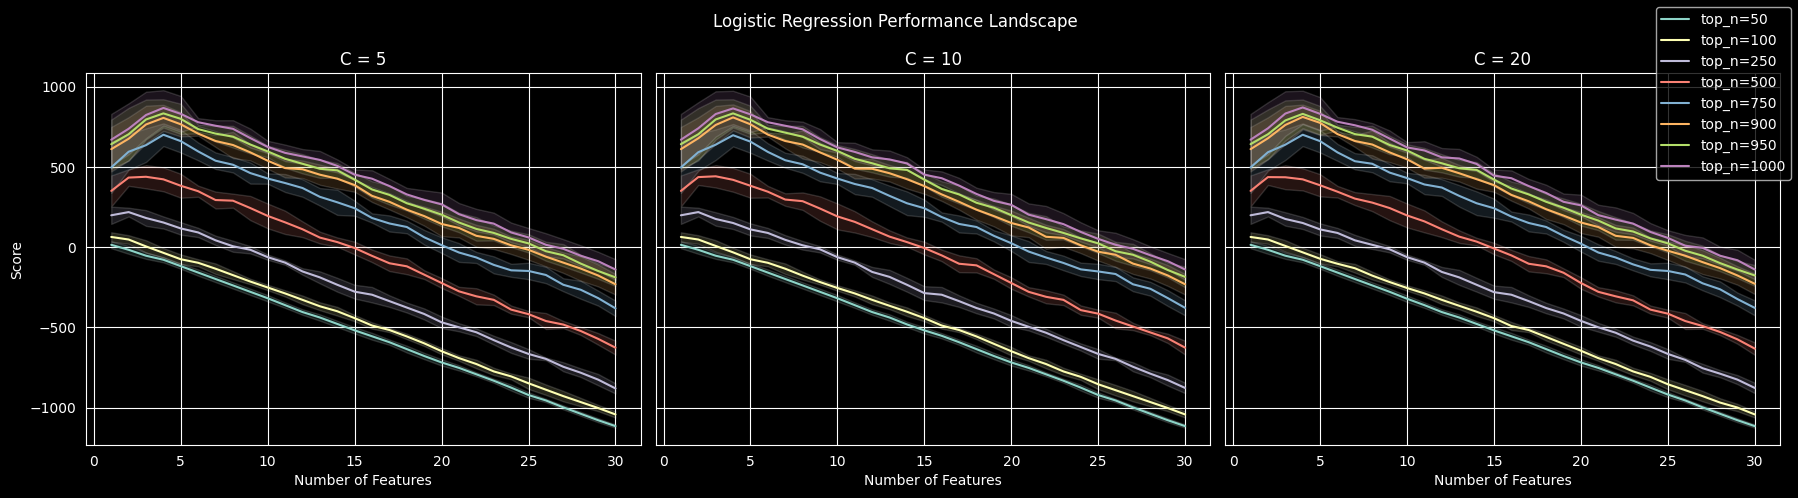

In [6]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="C",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)